# 1. Imports.

In [226]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt

# 2. Data preparation
### 2.1. Load the data

In [227]:
data = pd.read_csv('census-income/adult.csv', na_values='?')
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2.2. Filtering unwanted features

we only need discrete features as for the naive bayes model, we need to count the number of occurences of an event, which only works for distinct categorized feeatures.

In [245]:
data_filtered = data.drop(columns=["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]) # features only include discrete variables

data_filtered.head()

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
0,NaN,HS-grad,Widowed,NaN,Not-in-family,White,Female,United-States,<=50K
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
2,NaN,Some-college,Widowed,NaN,Unmarried,Black,Female,United-States,<=50K
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,United-States,<=50K
4,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,United-States,<=50K


### 2.3. Handling missing values

we'll assume that missing values in features as a distinct category in that feature, which is better than removing them frm the dataset which will reduce the number of samples used to train the model and overall lower the performance.

In [248]:
for col in data_filtered.columns:
    data_filtered[col] = data_filtered[col].fillna("MISSING")
    data_filtered[col] = data_filtered[col].replace("?", "MISSING")

    print(data_filtered[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
MISSING              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

(we could tell from the value counts there are alot of missing values above) 

### 2.4. Encoding the data

This step turns each distinct category to a unique number which not only reduces memory usage but also speeds up the computation compared to strings. 

In [230]:
data_encoded = pd.DataFrame()
for col in data_filtered.columns:
    data_encoded[col] = data_filtered[col].astype('category')
    data_encoded[col] = data_encoded[col].cat.codes

data_encoded.head()

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
0,2,11,6,6,1,4,0,39,0
1,4,11,6,3,1,4,0,39,0
2,2,15,6,6,4,2,0,39,0
3,4,5,0,7,4,4,0,39,0
4,4,15,5,10,3,4,0,39,0


### 2.5. Separating data to features and targets

In [231]:
x = data_encoded.drop(columns=["income"])
y = data_encoded["income"]

x.head()

,workclass,education,marital.status,occupation,relationship,race,sex,native.country
0,2,11,6,6,1,4,0,39
1,4,11,6,3,1,4,0,39
2,2,15,6,6,4,2,0,39
3,4,5,0,7,4,4,0,39
4,4,15,5,10,3,4,0,39


### 2.6. Splitting data

In [232]:
# first split 70% training and 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size = 0.29999, random_state = 42, stratify = y)

# then split temp into 15% validation and 15% test
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

In [233]:
print(f"Training set size: {x_train.shape[0]} samples")
print(f"Validation set size: {x_val.shape[0]} samples")
print(f"Test set size: {x_test.shape[0]} samples")

Training set size: 22793 samples
Validation set size: 4884 samples
Test set size: 4884 samples


# 3. Naive bayes implementation


The goal of the classifier is to determine the **Posterior Probability** of a class $C_k$ (e.g., $C_k = \text{'>50K'}$), given a new sample with features $\mathbf{x}$.

Bayes' Theorem provides the fundamental relationship:

$$P(C_k | \mathbf{x}) = \frac{P(\mathbf{x} | C_k) P(C_k)}{P(\mathbf{x})}$$

The prediction rule simplifies to finding the class $C_k$ that maximizes the numerator:

$$\text{Predict } C_k \propto P(\mathbf{x} | C_k) \times P(C_k)$$

Where:
* $\mathbf{P(C_k | \mathbf{x})}$: The **Posterior Probability** (What we are classifying).
* $\mathbf{P(\mathbf{x} | C_k)}$: The **Likelihood** (Probability of observing the features given the class).
* $\mathbf{P(C_k)}$: The **Class Prior** (The overall probability of the class).



The model earns its name "Naïve" from the critical assumption it makes to simplify the Likelihood calculation.

The model assumes that **all features are conditionally independent** given the class $C_k$. This means that knowing the value of one feature (e.g., `education`) tells you nothing about the value of another feature (e.g., `workclass`), *once the class is known*.

This assumption allows the Likelihood term to be factored into a simple product:

$$\text{Predict } C_k = \arg\max_{k} \left[ P(C_k) \prod_{i=1}^{D} P(x_i | C_k) \right]$$


Our custom model relies on **frequency counts** of the discrete/categorical features. We use **Laplace smoothing** (the $\alpha$ term) to ensure that if a combination is not seen in the training data, its probability is not zero.

 * Class Prior ($P(C_k)$)

$$P(C_k) = \frac{\text{Count}(\text{Class } C_k) + \alpha}{\text{Total Samples} + \alpha \times \text{Num Classes}}$$

 * Feature Likelihood ($P(x_i | C_k)$)

$$P(x_i | C_k) = \frac{\text{Count}(x_i \text{ in } C_k) + \alpha}{\text{Count}(\text{Class } C_k) + \alpha \times \text{Num Feature Values}}$$


Instead of multiplying many small probabilities (which causes **numerical underflow**), the model converts the multiplication into addition using logarithms (the **Log-Sum rule**).

$$\text{Log Score}(C_k | \mathbf{x}) = \log(P(C_k)) + \sum_{i=1}^{D} \log(P(x_i | C_k))$$

The final **prediction** is the class $C_k$ that yields the highest log score.


In [234]:
class NaiveBayes:
    def __init__(self, alpha = 1):
        self.alpha = alpha
        self.classPriors = {} # prior probabilities P(C)
        self.featureLikelihoods = {} # likelihood probabilities P(X|C)
        self.classes = None 
        self.featureValues = {}
        self.NKCounts = {}

    def fit(self, x_t, y_t):
        x = x_t.copy()
        y = y_t.copy()

        self.classes = np.unique(y)
        numClasses = len(self.classes)
        totalSamples = len(y)

        # claass prior
        for k in self.classes:
            nk = (y == k).sum()
            self.NKCounts[k] = nk

            # P(c) = (count of class + alpha) / (total samples + alpha * numClasses)
            self.classPriors[k] = (nk + self.alpha) / (totalSamples + self.alpha * numClasses)

        # posterior likelihoods
        for feat in x.columns:
            self.featureLikelihoods[feat] = {}

            uniqueValues = x[feat].max() + 1 
            self.featureValues[feat] = uniqueValues

            classFeatCounts = x.groupby(y)[feat].value_counts().unstack(fill_value=0)
            for k in self.classes:
                self.featureLikelihoods[feat][k] = {}
                nk = self.NKCounts[k]
                denominator = nk + self.alpha * uniqueValues

                for values in range(uniqueValues):
                    N_i_k = classFeatCounts.loc[k, values] if k in classFeatCounts.index and values in classFeatCounts.columns else 0
                    likelihood = (N_i_k + self.alpha) / denominator
                    self.featureLikelihoods[feat][k][values] = likelihood

    
    def predict(self, x_t, return_log_score = False):
        x = x_t.copy()
        predictions = []
        log_scores = []

        for _, sample in x.iterrows():
            score = {}
            for k in self.classes:
                score[k] = np.log(self.classPriors[k])

                for feat in x.columns:
                    feat_value = sample[feat]
                    likelihood = self.featureLikelihoods[feat][k].get(feat_value, self.alpha / (self.NKCounts[k] + self.alpha * self.featureValues[feat]))
                    score[k] += np.log(likelihood)
                
            pred = max(score, key=score.get)
            predictions.append(pred)

            log_score = [score[k] for k in self.classes]
            log_scores.append(log_score)
        
        if return_log_score:
            return np.array(predictions), np.array(log_scores)
        else:
            return np.array(predictions)
    

### 3.1. Hyperparameter tuning

We only have one parameter to hypertune which is the alpha ($\alpha$).

In [235]:
def hyper_tuning(x_tr, y_tr, x_vl, y_vl, alphas):
    x_t = x_tr.copy()
    y_t = y_tr.copy()
    x_v = x_vl.copy()
    y_v = y_vl.copy()

    accuracies = []

    for a in alphas:
        NB = NaiveBayes(alpha = a)

        NB.fit(x_t, y_t)
        y_pred = NB.predict(x_v)

        accuracy = accuracy_score(y_v, y_pred)
        accuracies.append(accuracy)
        print(f"Alpha: {a}, Validation Accuracy: {accuracy*100:.2f}")
    
    best_alpha = alphas[np.argmax(accuracies)]

    return best_alpha

In [236]:
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]

optimal_alpha = hyper_tuning(x_train, y_train, x_val, y_val, alphas)

print(f"Optimal alpha = {optimal_alpha}")

Alpha: 0.1, Validation Accuracy: 79.24
Alpha: 0.5, Validation Accuracy: 79.22
Alpha: 1.0, Validation Accuracy: 79.18
Alpha: 2.0, Validation Accuracy: 79.16
Alpha: 5.0, Validation Accuracy: 79.12
Optimal alpha = 0.1


* If we put  $\alpha = 0$ there wont be any smoothing and if a feature likelihood ($P(x_i | C_k)$) is equal zero the whole Posterior Probability ($\mathbf{P(C_k | \mathbf{x})}$) equals zero

* When $\alpha$ equals a small value (e.g. 0.1, 0.5), This helps regularize the model, preventing zero probabilities and improving performance on unseen data.

* When $\alpha$ equals a large value (e.g. 100), The model loses the unique patterns learned from the data, leading to underfitting.

# 4. Analysis and evaluation

### 4.1. Evaluation

In [237]:
final_model = NaiveBayes(alpha = optimal_alpha)
final_model.fit(x_train, y_train)
y_pred_test, log_scores = final_model.predict(x_test, return_log_score = True)

final_accuracy = accuracy_score(y_test, y_pred_test)
final_f1 = f1_score(y_test, y_pred_test)
print(f"Test accuracy : {final_accuracy * 100:.2f}%")

Test accuracy : 78.93%


### 4.2. Feature selection

To understand the impact of specific features on the model's performance, an ablation study was conducted where each feature was individually removed ("neglected") from the training set, and the model was re-evaluated.

**Base Model Accuracy:** ~78.93%

| Feature Neglected | New Accuracy | Impact Analysis |
| :--- | :--- | :--- |
| **Education** | **75.86%** | **High Impact:** Accuracy dropped significantly, indicating `education` is a crucial predictor for income. |
| **Occupation** | **76.72%** | **High Impact:** Similar to education, `occupation` is a strong signal for income classification. |
| **Native Country** | 78.75% | **Low Impact:** Removing this resulted in a negligible accuracy drop. |
| **Race** | 78.77% | **Low Impact:** Minimal change in performance. |
| **Workclass** | 78.91% | **Neutral:** Almost no change from the base accuracy. |
| **Sex** | 79.16% | **Slight Improvement:** Removing `sex` slightly improved the model, suggesting it may have added minor noise. |
| **Marital Status** | **81.37%** | **Negative Impact (Confusion):** Removing this *increased* accuracy significantly. This suggests `marital.status` might be highly correlated with `relationship`, causing "double counting" issues typical in Naive Bayes. |
| **Relationship** | **81.67%** | **Negative Impact (Confusion):** Removing this resulted in the highest accuracy increase, confirming redundancy with `marital.status`. |

---

In [238]:
features = ["workclass", "education", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]
feat_acc = []

for feat in features:
    x_drop_train = x_train.drop(columns=[feat])
    x_drop_test = x_test.drop(columns=[feat])

    nb = NaiveBayes(alpha = optimal_alpha)
    nb.fit(x_drop_train, y_train)
    y_drop_pred = nb.predict(x_drop_test)

    acc = accuracy_score(y_test, y_drop_pred)
    print(f"Accuracy after neglecting {feat} = {acc * 100:.2f}")

    feat_acc.append(acc)



Accuracy after neglecting workclass = 78.91
Accuracy after neglecting education = 75.86
Accuracy after neglecting marital.status = 81.37
Accuracy after neglecting occupation = 76.72
Accuracy after neglecting relationship = 81.67
Accuracy after neglecting race = 78.77
Accuracy after neglecting sex = 79.16
Accuracy after neglecting native.country = 78.75


### 4.3. Probability Analysis

##### 4.3.1. Getting the confidence

In [239]:
#convert the log scores to probabilities
exp_scores = np.exp(log_scores - np.max(log_scores, axis=1, keepdims=True))
probabilities = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

confidence = np.max(probabilities, axis=1)
predicted_class_index = np.argmax(probabilities, axis=1)

y_test_arr = y_test.values
is_correct = (predicted_class_index == y_test_arr)

confidence_correct = confidence[is_correct]
confidence_incorrect = confidence[~is_correct]

##### 4.3.2. Plotting histogram

The histogram visualizes the distribution of confidence scores for **Correct** (Green) vs. **Incorrect** (Red) predictions.
* **Correct Predictions:** Heavily skewed towards high confidence (0.9 - 1.0). The model is generally "sure" when it is right.
* **Incorrect Predictions:** Spread more evenly across lower confidence intervals (0.5 - 0.8). This indicates that when the model makes a mistake, it is often "uncertain," making the probability score a useful metric for filtering unreliable predictions.

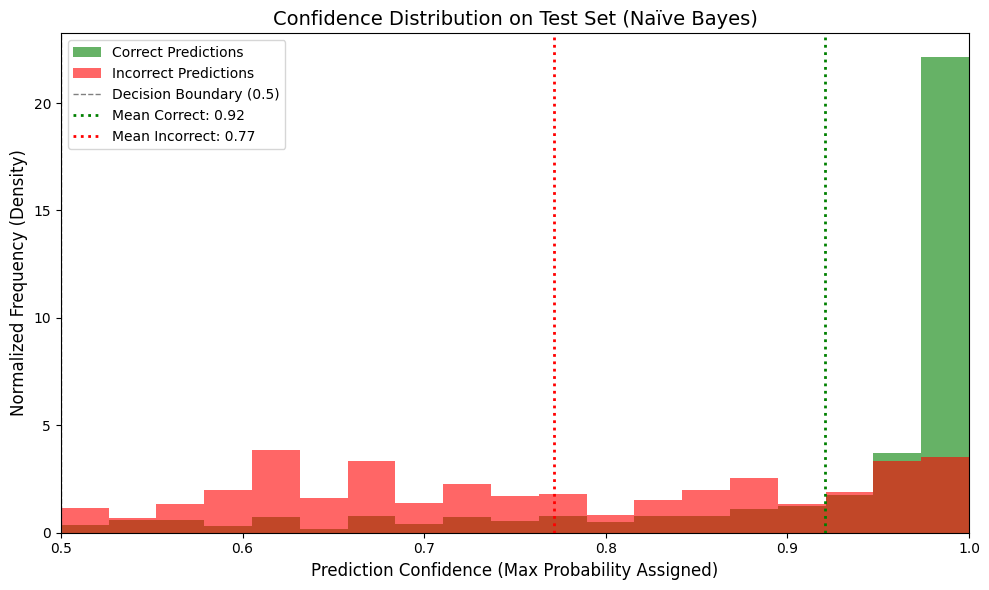

In [240]:
plt.figure(figsize=(10, 6))
plt.hist(confidence_correct, bins=np.linspace(0.5, 1.0, 20), alpha=0.6, label='Correct Predictions', color='green', density=True)
plt.hist(confidence_incorrect, bins=np.linspace(0.5, 1.0, 20), alpha=0.6, label='Incorrect Predictions', color='red', density=True)
plt.title('Confidence Distribution on Test Set (Naïve Bayes)', fontsize=14)
plt.xlabel('Prediction Confidence (Max Probability Assigned)', fontsize=12)
plt.ylabel('Normalized Frequency (Density)', fontsize=12)
plt.xlim(0.5, 1.0) 
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Decision Boundary (0.5)')
try:
    plt.axvline(x=np.mean(confidence_correct), color='green', linestyle=':', linewidth=2, label=f'Mean Correct: {np.mean(confidence_correct):.2f}')
    plt.axvline(x=np.mean(confidence_incorrect), color='red', linestyle=':', linewidth=2, label=f'Mean Incorrect: {np.mean(confidence_incorrect):.2f}')
except ValueError:
    pass 
plt.legend()
plt.tight_layout()
plt.show()

### 4.4. Comparing model with SKLearn

##### Key Observations
1.  **Accuracy Gap:** The manual implementation outperformed Sklearn by approximately **5%** (79% vs 74%).
2.  **Recall Sensitivity:** The manual model had a significantly higher Recall for the minority class (`>50K`) at **0.72** compared to Sklearn's **0.45**.
3.  **Why the difference?**
    * The manual implementation likely handles **Laplace Smoothing ($\alpha$)** or **Category Encoding** differently than the generic `MultinomialNB`.
    * `MultinomialNB` in Sklearn is typically designed for integer counts (like word frequencies in NLP). If the categorical encoding (0, 1, 2...) was treated purely as magnitudes rather than categorical matches, Sklearn's assumption might not fit this tabular census data as well as the custom probability lookup used in the manual class.

**Conclusion:** The Manual implementation is better suited for this specific categorical dataset than the out-of-the-box Multinomial Naive Bayes.

In [241]:
nb_sklearn = MultinomialNB(alpha = optimal_alpha)
nb_sklearn.fit(x_train, y_train)
y_sklearn_pred = nb_sklearn.predict(x_test)

Classification report for the manual model:

              precision    recall  f1-score   support

       <=50K       0.90      0.81      0.85      3708
        >50K       0.55      0.72      0.62      1176

    accuracy                           0.79      4884
   macro avg       0.72      0.77      0.74      4884
weighted avg       0.82      0.79      0.80      4884



<Figure size 800x600 with 0 Axes>

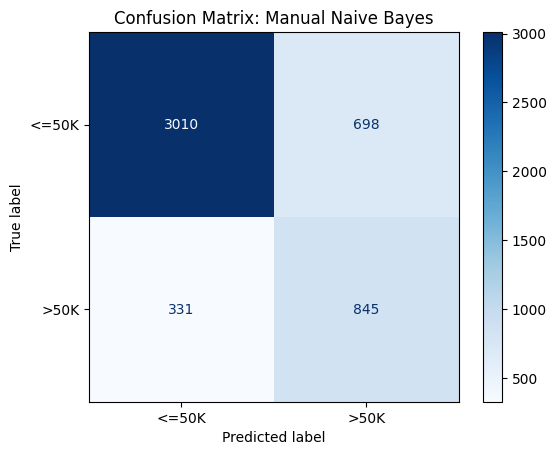

In [242]:
print(classification_report(y_test, y_pred_test, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Manual Naive Bayes")
plt.show()

Classification report for SKLearn model

              precision    recall  f1-score   support

       <=50K       0.83      0.84      0.83      3708
        >50K       0.47      0.45      0.46      1176

    accuracy                           0.74      4884
   macro avg       0.65      0.64      0.65      4884
weighted avg       0.74      0.74      0.74      4884



<Figure size 800x600 with 0 Axes>

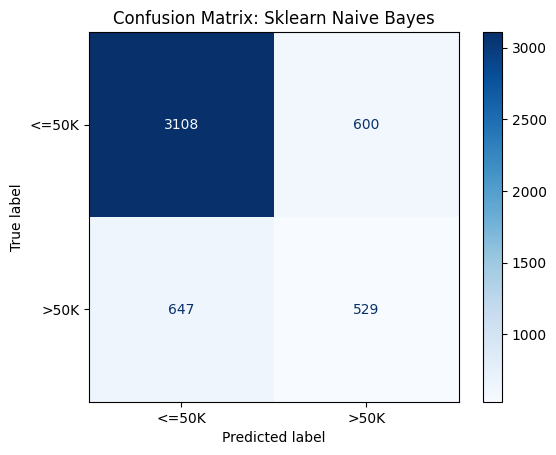

In [243]:
print(classification_report(y_test, y_sklearn_pred, target_names=["<=50K", ">50K"]))

cm_sklearn = confusion_matrix(y_test, y_sklearn_pred)
disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=["<=50K", ">50K"])
plt.figure(figsize=(8, 6))
disp_sklearn.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Sklearn Naive Bayes")
plt.show()

# 5. Independence violation

The fundamental assumption of the Naïve Bayes classifier is that all features are **conditionally independent** given the target class. This means the model assumes that knowing one feature (e.g., `marital.status`) gives no extra information about another feature (e.g., `relationship`) once the income class is known.

However, real-world data often violates this assumption. Our **Feature Selection (Ablation Study)** results in Section 4.2 provide strong evidence of this violation.

#### 1. Evidence of Violation
When we individually removed specific features, we observed a surprising **increase** in model accuracy:

* **Base Model Accuracy:** 78.93%
* **Accuracy without `marital.status`:** **81.37%** (+2.44%)
* **Accuracy without `relationship`:** **81.67%** (+2.74%)

This significant performance boost suggests that `marital.status` and `relationship` are **highly correlated** (redundant). For example, if a person's `relationship` is "Husband", their `marital.status` is almost certainly "Married".

#### 2. Impact on the Model ("Double Counting")
When two features are highly correlated, Naïve Bayes essentially **"double counts"** that information.

* **Probability Inflation:** Because the model multiplies probabilities (or adds log-scores), having two features effectively saying the same thing pushes the posterior probability too far in one direction.
* **Reduced Accuracy:** Instead of reinforcing the correct prediction, this redundancy biases the model, making it overconfident in potentially wrong classifications or distorting the decision boundary.

**Conclusion:**
Violating the independence assumption by including redundant features (like *Marital Status* and *Relationship*) actually **hurt** our model's performance. Removing the redundant feature allowed the model to generalize better, raising accuracy from ~79% to ~81.7%.